# A/B Testing Experiment

This notebook goes through an A/B testing scenario end-to-end, from understanding the business context to designing a hypothesis test and interpreting the results. I was greatly inspired by this [Notebook](https://github.com/renatofillinich/ab_test_guide_in_python/blob/master/AB%20testing%20with%20Python.ipynb) by renatofillinich, but wanted to expand on some considerations that are important from a business / non-technical stakeholder POV. Note that this notebook presumes a working knowledge of statistics already; some useful links for additional reading are provided at the end. 

#### Table of contents
1. [The Problem Statement](#1-the-problem-statement)
2. [Designing the Experiment](#2-designing-the-experiment)
3. [Data collection](#3-data-collection)
4. [Run hypothesis test](#4-run-hypothesis-test)
5. [Validity checks](#5-validity-checks)
6. [Deciding to launch](#6-deciding-to-launch)
7. [References](#7-references)

***
## 1. The Problem Statement

The problem:

> You are a data scientist in FaceGram company's product analytics team. FaceGram is a social media platform with an optional paid subscription that unlocks additional features. As always, the product team is trying to innovate on how to get more basic users converted to premium users. They're looking to test out a new tweak to the algorithm that informs when and how often users are shown a prompt / advert to subscribe to premium, aiming ideally for a 1pp (1 % point) conversion rate increase from the  observed baseline conversion rate of 12%.
That's where you come in!

Being an esteemed data scientist, you suggest to run an A/B test on a subset of users. Here is where the importance of understanding the business's goals comes in. From prior experience (and reading a ton of Trustworthy Online Controlled Experiments by Kohavi, Tang and Xu), you can make a few key decisions:
1. Based on existing user conversion being the focus, it makes sense that the **randomization unit is user** or user_id
2. Clearly, the **Evaluation Metric** we need to test for is **conversion rate**. The focus is on the "existing user" layer of the product funnel, and progressing them to "premium user"
3. However, we also want a **guardrail metric** in **Average Revenue Per User (ARPU)** - you know that premium subscriptions are a revenue driver, but so too is ad watch time. Being a zillennial social media user yourself, you're keenly aware that UX changes can have adverse effects on total app usage (and therefore total watchtime). This one might draw more users to convert but lower overall user usage & retention, resulting in a net loss in revenue!

***
## 2. Designing the Experiment

Now, the fun stuff. Let's focus on the Evaluation Metric for now - conversion rate is a proportional metric (converted users / all users), hence the best test is a **chi-square test**. We want the test to be two-tailed, since we're not certain whether this change will improve or worsen conversion rates (if any change at all). Per hypothesis testing conventions, let's formulate the null and alternate hypotheses:
$$H_0: p = p_0$$
$$H_a: p \ne p_0$$
where $p$ and $p_0$ stand for the conversion rate of the new and old algorithms, respectively. In English terms, the null hypothesis is that both algos perform the same in terms of conversion, while the alternate is that they do not.

Let's also set a couple of parameters:
* $\alpha$ = 0.05, equivalent to a confidence level of 95%. In essence, this says that we will tolerate a 5% (or less) chance of a false positive (what stat nerds call a Type I error)
* **Power of the test** ($1 - \beta$) = 80%. This tells us the probability we'll correctly identify differing conversion rates, limiting the chance of a false negative to 20% (aka Type II error)
* **Effect size** tells us the magnitude of change that we're trying to detect. The math behind calculating effect size requires:
    * An assumed baseline conversion rate - for our example, let's use **12%**, which is the long-term observed conversion rate of the current algorithm in this scenario
    * A **minimum detectable effect (MDE)** we'd like to identify. For the latter, we can use the **1pp** uplift the product team is targetting.

At this point, we also want to undertake a **power analysis**; a lot of complex math that python libraries thankfully do for us to make sure we're sampling enough people for the magnitude of change that we'd expect and ideally want to detect. As you might guess, all 3 above parameters inform this analysis and exist in a 4-way dependency with sample size.

In [37]:
# import required packages
import numpy as np
import pandas as pd
import statsmodels.stats.api as sms
import math as mt

In [38]:
effect_size = sms.proportion_effectsize(0.12, 0.13)  # Calculating effect size from (assumed baseline rate, assumed baseline rate + MDE)
# For further reading - a chi-square / Z-test uses Cohen's h, but other test statistics use differing effect size estimation methods.

required_n = sms.NormalIndPower().solve_power( # Calculating sample size needed
    effect_size, 
    power=0.8, 
    alpha=0.05, 
    ratio=1
    ) 

required_n = mt.ceil(required_n) # Rounding up to next whole number                          

print(f"Minimum required sample size: {required_n}.")

Minimum required sample size: 17164.


***
## 3. Data Collection

In real life, data collection typically comes after identifying the required sample size. You'd work with data/analytics engineers to ensure proper instrumentation is (a) capturing the necessary data needed for the experiment (b) fairly and randomly assigning the quota of users (or whatever randomisation unit) to the control or treatment group. This is because we want to determine a set sample size beforehand to avoid any potential of **'p-hacking'** (essentially, picking and choosing samples and/or sample sizes with the intent of getting a statistically significant result). Unfortunately, this is a fictional scenario, hence we'll be using the same pre-made dataset that renatofillinich uses.

[Download ab_data.csv]('https://www.kaggle.com/zhangluyuan/ab-testing?select=ab_data.csv')

On the upside, this means we can skip having to work with the analytics engineers to make sure the right tools are set up to capture the right info at the right intervals for our experiment. As an aside, it's typical for data to be collected over the course of 2+ weeks to avoid weekday and seasonality biases. While ongoing monitoring can be good for checking for instrumentation errors, it's crucial not to stop mid-experiment just because the current cut of data indicates something interesting. This is another form of p-hacking. Don't give the product team false hope!

In [39]:
df = pd.read_csv("Inputs/ab_data.csv") # Download ab_data.csv from link in above markdown. Alternatively, the file can be found on this notebook's repo
df = df.drop('landing_page', axis=1) # The original dataset was for a webpage scenario; ours is for an ad algorithm. Hence, drop the non-applicable column

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    294478 non-null  int64
 1   timestamp  294478 non-null  str  
 2   group      294478 non-null  str  
 3   converted  294478 non-null  int64
dtypes: int64(2), str(2)
memory usage: 9.0 MB


,user_id,timestamp,group,converted
0,851104,2017-01-21 22:11:48.556739,control,0
1,804228,2017-01-12 08:01:45.159739,control,0
2,661590,2017-01-11 16:55:06.154213,treatment,0
3,853541,2017-01-08 18:28:03.143765,treatment,0
4,864975,2017-01-21 01:52:26.210827,control,1


Let's undertake some data cleaning exercises to make sure our analysis is not disrupted by faulty data.

In [40]:
# 1. Identify control and treatment groups are unique and mutually exclusive
duplicated_users = df.groupby('user_id')['group'].nunique()
users_in_both = duplicated_users[duplicated_users > 1]

print(f"Users in both groups: {len(users_in_both)}")

Users in both groups: 1895


...not a great sign, and in real life cause to question the underlying instrumentation and re-run the experiment. For our analysis, let's persevere by simply removing these cases entirely from the analysis.

In [41]:
df2 = df[~df['user_id'].isin(users_in_both.index)].copy()

print( df2['user_id'].count() )

290688


Let's also make sure that no users are double-counted within groups.

In [42]:
print( f'# of user_id rows: {df2['user_id'].count()}, unique count of user_id: {df2['user_id'].nunique()}' )


# of user_id rows: 290688, unique count of user_id: 288689


In [43]:
# 288689 unique ids across 290688. Let's remove the duplicates that clearly exist 
df2.drop_duplicates(subset ='user_id',keep ='first',inplace = True)

df2.info() # Final check for soundness

<class 'pandas.DataFrame'>
Index: 288689 entries, 0 to 294477
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    288689 non-null  int64
 1   timestamp  288689 non-null  str  
 2   group      288689 non-null  str  
 3   converted  288689 non-null  int64
dtypes: int64(2), str(2)
memory usage: 11.0 MB


Finally, let's randomly sample $required_n$ amount of users in each group. Again, in a real-life scenario, the instrumentation should target $n$ amount of users beforehand to eliminate biases (not to mention implementation and operational costs of exposing experimental changes to much larger cohorts than needed).

In [44]:
# Using random_state = 7 to return a fixed result on repeat runs.
control_sample = df2[df2['group'] == 'control'].sample(n=required_n, random_state=7)
treatment_sample = df2[df2['group'] == 'treatment'].sample(n=required_n, random_state=7)

# Append control and treatment samples
ab_test = pd.concat([control_sample, treatment_sample], axis=0)
ab_test.reset_index(drop=True, inplace=True) #reset index

ab_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 34328 entries, 0 to 34327
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   user_id    34328 non-null  int64
 1   timestamp  34328 non-null  str  
 2   group      34328 non-null  str  
 3   converted  34328 non-null  int64
dtypes: int64(2), str(2)
memory usage: 1.0 MB


***
## 4. Run hypothesis test

With our data clean, let's actually test our hypothesis. Plugging into chi-square test, which for 2 iid samples is equivalent to a two-proportion Z-test.

In [45]:
from statsmodels.stats.proportion import proportions_ztest

control_results = ab_test[ab_test['group'] == 'control']['converted']
treatment_results = ab_test[ab_test['group'] == 'treatment']['converted']

successes = [control_results.sum(), treatment_results.sum()]
nobs = [control_results.count(), treatment_results.count()]

z_stat, pval = proportions_ztest(successes, nobs=nobs)

print(f'Z-stat: {z_stat:.3f}')
print(f'p-value: {pval:.3f}')

Z-stat: -0.925
p-value: 0.355


The p-value of 0.355 is > $\alpha$ (0.05), which means we do not have sufficient evidence to reject the null hypothesis.

In [46]:
from statsmodels.stats.proportion import proportion_confint

(lower_con, lower_treat), (upper_con, upper_treat) = proportion_confint(successes, nobs=nobs, alpha=0.05)

control_rate = successes[0] / nobs[0]
treatment_rate = successes[1] / nobs[1]

print(f'Control observed rate: {control_rate :.3f} | Control 95% CI: [{lower_con:.3f}, {upper_con:.3f}]')
print(f'Treatment observed rate: {treatment_rate :.3f} | Treatment 95% CI: [{lower_treat:.3f}, {upper_treat:.3f}]')

Control observed rate: 0.120 | Control 95% CI: [0.115, 0.125]
Treatment observed rate: 0.123 | Treatment 95% CI: [0.118, 0.128]


Furthermore, if we think of both the Control and Treatment groups as independent samples from the same population (under the null hypothesis at least), we can take a look at their respective 95% confidence intervals (CI). Doing so, we can see that while the Treatment group had a 0.3% observed conversion rate, its CI overlaps a good amount with the Control group's.

__Note:__ the ultimate determinant of statistical significance for a 2-proportion test is the __p-value__. Just because CI's overlap does not mean a statistically insignificant result. Fortunately in this case, the p-value aligns with what the CI overlap suggests - statistically insignificant results.

***
## 5. Validity Checks

Now typically if you fail to detect a statistically significant uplift in your primary Evaluation Metric, there's little reason to look at your Guardrail Metric(s). But let's do so here for illustrative purposes. Specifically, we'll be assessing if there is a statistical significant difference in (ARPU), as mentioned in section 1. First, download the below curated dataset.

[Download ab_data_rev_user.csv](https://github.com/ericyunliu-blip/Python/blob/main/ab_data_rev_user.csv)

In [47]:
df_rev = pd.read_csv('Inputs/ab_data_rev_user.csv') # Download ab_data.csv from link in above markdown

df_rev.info()

<class 'pandas.DataFrame'>
RangeIndex: 290584 entries, 0 to 290583
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  290584 non-null  int64  
 1   group    290584 non-null  str    
 2   rev      290584 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 6.7 MB


Let's fetch the Control and Treatment groups from our 3. Data Collection step.

In [48]:
rev_control = df_rev[df_rev['user_id'].isin(control_sample['user_id'])]
rev_treatment = df_rev[df_rev['user_id'].isin(treatment_sample['user_id'])]

# Append control and treatment samples
rev_ab_test = pd.concat([rev_control, rev_treatment], axis=0)
rev_ab_test.reset_index(drop=True, inplace=True) #reset index

rev_ab_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 34328 entries, 0 to 34327
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  34328 non-null  int64  
 1   group    34328 non-null  str    
 2   rev      34328 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 804.7 KB


...and conduct a hypothesis test with the same framework as our evaluation metric (H):
* $H_0: \mu_{treatment} = \mu_{control}$
* $H_1: \mu_{treatment} \neq \mu_{control}$
* $\alpha$ = 0.05

The major difference is, while our Evaluation Metric (conversion rate) is a proportion, our Guardrail Metric (Average Revenue per User) is an _average_. Hence, we'll use Welch's t-test for this metric. Let's fetch the p-value and corresponding confidence interval.

In [49]:
from scipy.stats import ttest_ind

rev_stat, rev_p = ttest_ind( rev_control['rev'], rev_treatment['rev'], equal_var=False )
# Note: safer to assume unequal variance.

print(f"T-statistic: {rev_stat:.3f}")
print(f"P-value: {rev_p:.3f}")

T-statistic: 3.053
P-value: 0.002


In [50]:
from statsmodels.stats.weightstats import zconfint

lower_c, upper_c = zconfint(rev_control['rev'], alpha=0.05)
lower_t, upper_t = zconfint(rev_treatment['rev'], alpha=0.05)

rev_control_mean = rev_control['rev'].mean()
rev_treatment_mean = rev_treatment['rev'].mean()

print(f'Control mean: {rev_control_mean :.3f} | Control 95% CI: [{lower_c:.3f}, {upper_c:.3f}]')
print(f'Treatment mean: {rev_treatment_mean :.3f} | Treatment 95% CI: [{lower_t:.3f}, {upper_t:.3f}]')

Control mean: 6.196 | Control 95% CI: [6.112, 6.280]
Treatment mean: 6.013 | Treatment 95% CI: [5.931, 6.095]


Based on the p-value 0.002 < $\alpha$ 0.05, we can actually see a statistically significant decline in ARPU in contrast to the statistically non-significant uptick in conversions, supported by the treatment group's confidence intervals.

Visualizing the results for further clarity of the metric trade-off

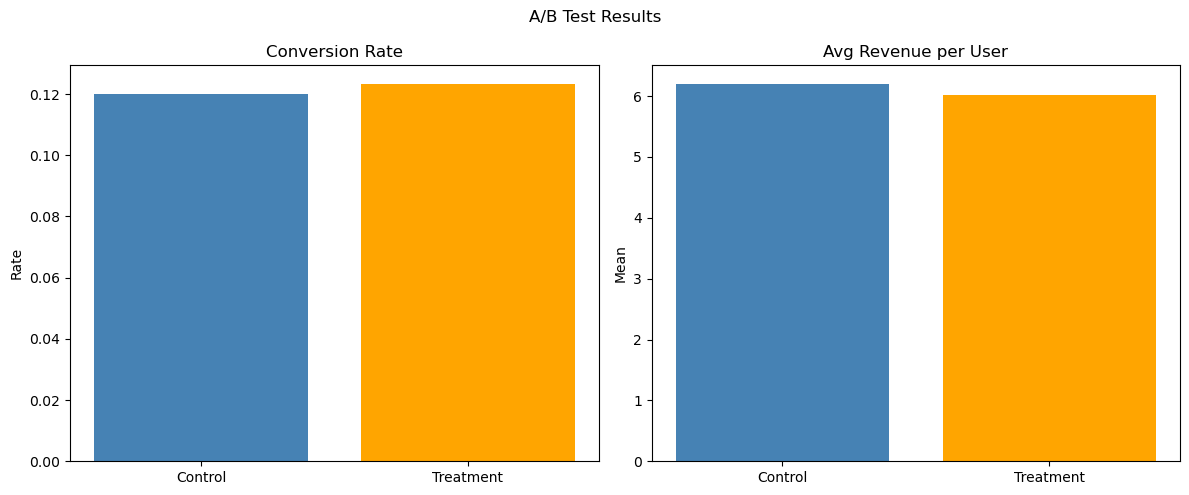

In [54]:
import matplotlib as mpl
import matplotlib.pyplot as plt

labels = ['Control', 'Treatment']
ctr_vals = [control_rate, treatment_rate]
rev_vals = [rev_control_mean, rev_treatment_mean]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Conversion Rate plot
ax1.bar(labels, ctr_vals, color=['steelblue', 'orange'])
ax1.set_title('Conversion Rate')
ax1.set_ylabel('Rate')

# Revenue plot
ax2.bar(labels, rev_vals, color=['steelblue', 'orange'])
ax2.set_title('Avg Revenue per User')
ax2.set_ylabel('Mean')

fig.suptitle('A/B Test Results')
plt.tight_layout()
plt.show()

There are a few more validity checks that you should consider, but are out-of-scope for being detailed within this notebook. These include:
1. Consider running a concurrent __A/A test__ (comparing two control groups together) to check for the risk of instrumentation error or selection bias. The thought process is: two randomly sampled control groups should not yield statistically significant differences. If they do, it's a sign of a bug somewhere, e.g. faulty data capture, non-random sampling, and a call-to-action to investigate and possibly re-run the experiment.
2. Assess if any __external factors__ could impact the results. For example, if FaceGram is currently undergoing a famous class action lawsuit, that could very much damper the conversion rate uplift that otherwise would occur with a more aggressive premium recommendation algorithm.
3. In real life, each sample (i.e. each control and treatment group) should be selected during the course of the experiment, rather than randomly choosing exactly 17,164 users from a larger pool of each group retrospectively. This means the experiment may be subject to a __Sample Ratio Mismatch__ (SRM), which can introduce bias to your results. Now if the control:treatment ratio was 1:100, that's obvious. In less obvious cases such as 49:51, applying a goodness-of-fit statistical test can help minimize the possibility of SRM-related faults.
4. Lastly, be aware of the potential for __novelty and primacy effects__ to skew your results - that is; sometimes metric differences are driven moreso by the novelty of a brand new feature, or attachment to the familiar, rather than genuine improvement in UX / user satisfaction. Segmenting your user cohorts by old vs new users and only comparing old vs old and new vs new (with some workable definition of what constitutes "new") can help control for these effects. For our specific scenario, we're looking at tweaks to a backend algorithm rather than a new feature or visible front-end change, hence these effects are less likely to be impactful.


***
## 6. Deciding to Launch

It's 2-3 weeks later, the experiment is finished, and you're just about to sip your coffee before you hear a proverbial knock on your ~~door~~ Slack channel. The product team is asking for results, wide-eyed and eager for good news. So what do you tell them?

* Even though the observed rate was 0.3% higher than the baseline, you could not rule out that this was due to just random chance. Not to mention, this fell far short of what the team considered to be a minimally practical uplift (1pp).
* Additionally, you relay that you did observe a slight but statistically significant backslide in average revenue per user.

__Clearly, you do not recommend FaceGram to implement the new premium recommendation algorithm.__ The product team is deflated, but glad that you were able to provide the right guidance. From here, this can be a jumping point to dive deeper into why there _wasn't_ an uplift, e.g. by looking at conversion in specific segments (country, platform etc.), and what lessons can be learnt for product decisions in the future.

___________________

In this scenario, it's a clear-cut decision to not recommend launching. But what if there was a statistically significant conversion rate increase? The product team needs to weigh that against the drop in revenue, alongside the cost of implementation and maintenance. ARPU was just an example Guardrail Metric; others may also need to be assessed based on relevance to the nature of the change. Post-launch monitoring will need to be done as well to make sure the new algo is matching up to expectations.

***
## 7. References

I have to give major credit to this [notebook](https://github.com/renatofillinich/ab_test_guide_in_python/blob/master/AB%20testing%20with%20Python.ipynb) by renatofillinich, which served as a jumping-off point for mine. I also used myzziah's [notebook](https://www.kaggle.com/code/myzziah/e-commerce-a-b-testing-full-experiment/notebook) as a source for further reading.

In addition to that, some other resources that informed the content here:
* Chopra, P. (2014) <i>Advanced A/B Testing Tactics That You Should Know</i>, Online-Behavior.com

* Esteller-Cucala, M.; Fernandez, V. & Villuendas, D. (2019) <i>Experimentation Pitfalls to Avoid in A/B Testing for Online Personalization</i>, ACM Digital Library

* Lewinson, E. (2018) <i>Introduction to Power Analysis in Python</i>, Towards Data Science

* Kohavi, R. & Longbotham, R. (2023) <i>Online Controlled Experiments and A/B Tests</i>, Encyclopedia of Machine Learning and Data Science

* Kohavi, R.; Tang, D. & Xu, Y. (2020) <i>Trustworthy Online Controlled Experiments - A practical guide to A/B Testing</i>, Cambridge University Press

* Sullivan, S. (2015) <i>Are you wasting time with A/A testing?</i>, Medium

* Vanagas, I. (2023) <i>Guardrail metrics for A/B tests, explained</i>, PostHog

* Volk-Jesussek, H. & Jesussek, M. (2024) <i>Confidence Interval: The right and wrong way to understand them.</i>, YouTube

* Wei, M. (2022) <i>How to Select the Right Statistical Tests for Different A/B Metrics</i>, Towards Data Science